# **1-Importing Important Libraries & Load Data:**

In [1]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from category_encoders import BinaryEncoder, TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# file_id_feature_extracted = '1xBjWsd38sOUfPn-vgCgkvWJfaatyVGmZ'
# https://drive.google.com/file/d/1yyl8eR4XgBl0E5NiZYpKd7zjUgCcrlP4/view?usp=drive_lin https://drive.google.com/file/d/17_vqkYrH_QIchjjFEkhKOs-oO6mEYPwy/view?usp=sharing
# file_id = '1t9Wu4KKfrAh7fxxojyr_LQlipsedqpZg'
# file_id = '17_vqkYrH_QIchjjFEkhKOs-oO6mEYPwy'
url = "/content/drive/MyDrive/Big_Data/dubizzle_apartments_enriched_llm.csv"
df = pd.read_csv(url)
# df = pd.read_csv('/content/dubizzle_apartments_llm_FINAL.csv')

/tmp/ipykernel_10398/2779142622.py:6: DtypeWarning: Columns (23,39,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [5]:
df_OLD = df.copy()

In [ ]:
df.head(3)

,url,scrape_timestamp,ad_id,title,price,price_numeric,bedrooms,bathrooms,area_sqm,area_numeric,...,has_roof,has_elevator,has_parking,has_pool,has_security,down_payment_egp,installment_years,monthly_installment_egp,floor_number,delivery_date
0,https://www.dubizzle.com.eg/en/ad/4-bedrooms-o...,2026-04-11T14:57:16.074456,503300413,4 Bedrooms Open View Apartment for Sale in Pal...,"EGP 11,300,000",11300000.0,5.0,4.0,255.0,255.0,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
1,https://www.dubizzle.com.eg/en/ad/apartment-fo...,2026-04-11T14:57:21.409146,503353829,Apartment for sale 200 m Al-Sarayya (direct se...,"EGP 10,500,000",10500000.0,3.0,2.0,320.0,320.0,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
2,https://www.dubizzle.com.eg/en/ad/apartment-fo...,2026-04-11T14:57:25.598458,503353292,"Apartment for sale, ready to move in, finished...","EGP 3,600,000",3600000.0,2.0,2.0,125.0,125.0,...,False,False,True,False,False,NaN,NaN,NaN,NaN,immediate


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73811 entries, 0 to 73810
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   url                      73811 non-null  object 
 1   scrape_timestamp         73811 non-null  object 
 2   ad_id                    73811 non-null  int64  
 3   title                    73800 non-null  object 
 4   price                    73796 non-null  object 
 5   price_numeric            73796 non-null  float64
 6   bedrooms                 73778 non-null  float64
 7   bathrooms                73779 non-null  float64
 8   area_sqm                 73747 non-null  float64
 9   area_numeric             73747 non-null  float64
 10  price_per_sqm            73516 non-null  float64
 11  property_type            73786 non-null  object 
 12  city                     73771 non-null  object 
 13  governorate              73771 non-null  object 
 14  latitude              

# **2- Drop Columns with more than 60% NULLs:**

In [8]:
df.isna().sum()/738.11
# df.isna().sum()

,0
url,0.000000
scrape_timestamp,0.000000
ad_id,0.000000
title,0.014903
price,0.020322
price_numeric,0.020322
bedrooms,0.044709
bathrooms,0.043354
area_sqm,0.086708
area_numeric,0.086708


In [9]:
#Drop over 60% Nulls Columns
for col in df.columns:
  if (df[col].isna().sum()/738.11) > 60:
    df = df.drop(col, axis=1)

In [10]:
df.isna().sum()/738.11
# df.isna().sum()

,0
url,0.000000
scrape_timestamp,0.000000
ad_id,0.000000
title,0.014903
price,0.020322
price_numeric,0.020322
bedrooms,0.044709
bathrooms,0.043354
area_sqm,0.086708
area_numeric,0.086708


# **3- Drop Non-Important Columns & Duplicated Rows:**

In [11]:
df.columns

Index(['url', 'scrape_timestamp', 'ad_id', 'title', 'price', 'price_numeric',
       'bedrooms', 'bathrooms', 'area_sqm', 'area_numeric', 'price_per_sqm',
       'property_type', 'city', 'governorate', 'latitude', 'longitude',
       'furnished', 'finish_type', 'ownership', 'payment_option',
       'completion_status', 'amenities', 'seller_name', 'seller_type',
       'posted_date', 'description', 'image_url', 'view_type', 'compound_name',
       'has_garden', 'has_roof', 'has_elevator', 'has_parking', 'has_pool',
       'has_security', 'delivery_date'],
      dtype='object')

In [12]:
#Drop not important Columns
cols = ['ad_id', 'title', 'price', 'description', 'image_url', 'url', 'scrape_timestamp']
df = df.drop(cols, axis=1)

In [13]:
df.columns

Index(['price_numeric', 'bedrooms', 'bathrooms', 'area_sqm', 'area_numeric',
       'price_per_sqm', 'property_type', 'city', 'governorate', 'latitude',
       'longitude', 'furnished', 'finish_type', 'ownership', 'payment_option',
       'completion_status', 'amenities', 'seller_name', 'seller_type',
       'posted_date', 'view_type', 'compound_name', 'has_garden', 'has_roof',
       'has_elevator', 'has_parking', 'has_pool', 'has_security',
       'delivery_date'],
      dtype='object')

In [14]:
df = df.drop_duplicates()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72320 entries, 0 to 73810
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_numeric      72316 non-null  float64
 1   bedrooms           72298 non-null  float64
 2   bathrooms          72299 non-null  float64
 3   area_sqm           72267 non-null  float64
 4   area_numeric       72267 non-null  float64
 5   price_per_sqm      72036 non-null  float64
 6   property_type      72306 non-null  object 
 7   city               72291 non-null  object 
 8   governorate        72291 non-null  object 
 9   latitude           72316 non-null  float64
 10  longitude          72316 non-null  float64
 11  furnished          61579 non-null  object 
 12  finish_type        46212 non-null  object 
 13  ownership          71880 non-null  object 
 14  payment_option     72193 non-null  object 
 15  completion_status  72299 non-null  object 
 16  amenities          58283 no

# **4- Handle Nulls in Numeric Columns (Fill with the Mean):**

In [16]:
df.select_dtypes(include='number').isna().sum()

,0
price_numeric,4
bedrooms,22
bathrooms,21
area_sqm,53
area_numeric,53
price_per_sqm,284
latitude,4
longitude,4


In [17]:
for col in df.select_dtypes(include='number').columns:
  df[col] = df[col].fillna(df[col].mean())

In [18]:
df.select_dtypes(include='number').isna().sum()

,0
price_numeric,0
bedrooms,0
bathrooms,0
area_sqm,0
area_numeric,0
price_per_sqm,0
latitude,0
longitude,0


# **5- Handle Nulls in Categorical Columns:**

## **5.1- For Over 10% NULLs Columns (Fill with "Unknown"):**



In [19]:
df.select_dtypes(include='object').isna().sum()

,0
property_type,14
city,29
governorate,29
furnished,10741
finish_type,26108
ownership,440
payment_option,127
completion_status,21
amenities,14037
seller_name,3357


In [20]:
df.select_dtypes(include='object').isna().sum()/728.42

,0
property_type,0.019220
city,0.039812
governorate,0.039812
furnished,14.745614
finish_type,35.841959
ownership,0.604047
payment_option,0.174350
completion_status,0.028830
amenities,19.270476
seller_name,4.608605


## **(NEW)- Fill (finish_type - view_type - compound_name - delivery_date) Nulls with ("Unknown"):**

In [21]:
df["furnished"] = df["furnished"].fillna("Unknown")
df["amenities"] = df["amenities"].fillna("Unknown")
df["finish_type"] = df["finish_type"].fillna("Unknown")
df["view_type"] = df["view_type"].fillna("Unknown")
df["compound_name"] = df["compound_name"].fillna("Unknown")
df["delivery_date"] = df["delivery_date"].fillna("immediate")

In [22]:
df["furnished"].value_counts()

,count
furnished,
No,56578
Unknown,10741
Yes,5001


In [23]:
df["amenities"].value_counts()

,count
amenities,
Unknown,14037
"Balcony, Built in Kitchen Appliances, Private Garden, Central A/C & heating, Security, Covered Parking, Maids Room, Pets Allowed, Pool, Electricity Meter, Water Meter, Natural Gas, Landline",3017
"Balcony, Private Garden, Security, Covered Parking, Pets Allowed, Pool, Electricity Meter, Water Meter, Natural Gas, Landline",1886
"Built in Kitchen Appliances, Private Garden, Covered Parking, Pets Allowed, Pool, Electricity Meter, Water Meter, Natural Gas, Landline",1600
"Balcony, Built in Kitchen Appliances, Private Garden, Central A/C & heating, Security, Covered Parking, Pets Allowed, Pool, Electricity Meter, Water Meter, Natural Gas, Landline",1537
...,...
"Balcony, Built in Kitchen Appliances, Security, Covered Parking, Maids Room, Electricity Meter, Natural Gas, Elevator",1
"Balcony, Private Garden, Central A/C & heating, Security, Covered Parking, Electricity Meter, Water Meter, Natural Gas, Elevator",1
"Balcony, Central A/C & heating, Security, Maids Room, Pool, Electricity Meter, Water Meter",1


## **(NEW)- Convert (has_garden - has_roof	- has_elevator) to bool:**

In [24]:
cols = ['has_garden', 'has_roof', 'has_elevator', 'has_parking', 'has_pool', 'has_security']

df[cols] = df[cols].replace({
    'True': True,
    'False': False,
    'TRUE': True,
    'FALSE': False,
    'true': True,
    'false': False
}).astype('boolean')

## **(NEW)- Convert (delivery_date) to float in terms of months:**

In [25]:
import re
import pandas as pd

now = pd.Timestamp.today().normalize()

def _normalize(v):
    s = str(v).strip()
    s = s.translate(str.maketrans("٠١٢٣٤٥٦٧٨٩٫", "0123456789."))
    s = s.replace("٬", "").replace(",", ".")
    return s.lower()

def _months_until(target):
    target = pd.Timestamp(target).normalize()
    if target <= now:
        return 0.0
    return float((target - now).days / 30.4375)

def parse_delivery_to_months(v):
    if pd.isna(v):
        return 0.0

    raw = _normalize(v)
    if raw in {"", "nan", "none"}:
        return 0.0

    phrase = re.sub(r"[\s\-_]+", " ", raw)
    phrase = re.sub(r"\s+", " ", phrase).strip()

    zero_exact = {
        "immediate", "immediately", "now",
        "ready", "ready to deliver", "ready to delivery", "ready for delivery",
        "ready for handover", "ready for living", "ready to receive",
        "ready to move", "ready to move in", "ready to move-in",
        "ready-to-move", "ready-to-move-in",
        "ready to delivered", "ready to deliverd",
        "delivered", "receipt", "rtm", "under construction",
        "first residence"
    }

    if phrase in zero_exact:
        return 0.0

    if phrase == "this year":
        return _months_until(pd.Timestamp(year=now.year, month=12, day=31))

    if phrase == "next year":
        return _months_until(pd.Timestamp(year=now.year + 1, month=1, day=1))

    if phrase == "current year":
        return 0.0

    approx_map = {
        "soon": 1.0,
        "near": 1.0,
        "near delivery": 1.0,
        "early": 1.0,
        "early delivery": 1.0,
        "upcoming": 1.0,
        "very soon": 0.5,
        "very close": 0.5,
        "few months": 3.0,
        "within 2 months": 2.0,
        "in 2 months": 2.0,
        "ready within 2 months": 2.0,
        "ready in 4 months": 4.0,
        "within 6 months": 6.0,
        "within a year": 12.0,
        "within one year": 12.0,
        "within two years": 24.0,
        "after 1 year": 12.0,
        "in one year": 12.0,
        "one year": 12.0,
        "6 months to a year": 9.0,
        "over 3 years": 48.0,
    }

    if phrase in approx_map:
        return approx_map[phrase]

    # ranges like 2024-2026 or 2024/2026 -> use the last year
    m = re.fullmatch(r"(\d{4})\s*[-/]\s*(\d{4})", raw)
    if m:
        year = int(m.group(2))
        if year < now.year:
            return 0.0
        return _months_until(pd.Timestamp(year=year, month=12, day=31))

    # standalone year like 2026
    m = re.fullmatch(r"(\d{4})", raw)
    if m:
        year = int(m.group(1))
        if year < now.year:
            return 0.0
        return _months_until(pd.Timestamp(year=year, month=12, day=31))

    # month-year like Jun-27 / Dec-26 / Jun 2027
    m = re.fullmatch(r"([a-z]{3,4})\s*[-/ ]\s*(\d{2}|\d{4})", raw)
    if m:
        month_map = {
            "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
            "jul": 7, "aug": 8, "sep": 9, "sept": 9, "oct": 10, "nov": 11, "dec": 12
        }
        mon = month_map.get(m.group(1))
        if mon:
            yr = int(m.group(2))
            if yr < 100:
                yr += 2000 if yr < 50 else 1900
            return _months_until(pd.Timestamp(year=yr, month=mon, day=1))

    # explicit durations like 6 months, 2.5 years, 4m
    m = re.search(r"\b(\d+(?:\.\d+)?)\s*(month|months|m|year|years|y)\b", phrase)
    if m:
        num = float(m.group(1))
        unit = m.group(2)
        return num if unit in {"month", "months", "m"} else num * 12.0

    # word durations like one year, two years
    word_num = {
        "one": 1, "two": 2, "three": 3, "four": 4, "five": 5, "six": 6,
        "seven": 7, "eight": 8, "nine": 9, "ten": 10, "eleven": 11, "twelve": 12
    }
    m = re.search(r"\b(one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve)\s*(month|months|year|years)\b", phrase)
    if m:
        num = word_num[m.group(1)]
        unit = m.group(2)
        return float(num if unit.startswith("month") else num * 12)

    # month name alone like "May" -> ambiguous, so 0
    if re.fullmatch(r"(jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)\b", raw):
        return 0.0

    # garbage numeric placeholders like 2019 / 1000 / 2
    if re.fullmatch(r"\d+", raw) and len(raw) <= 4:
        return 0.0

    # full date strings like 6/1/2025 or 2027-05-01T00:00:00.000Z
    dt = pd.to_datetime(raw, errors="coerce", utc=True, dayfirst=True)
    if pd.notna(dt):
        return _months_until(dt.tz_convert(None))

    return 0.0

# new column as float
df["delivery_date"] = df["delivery_date"].apply(parse_delivery_to_months).astype("float64")

In [26]:
df['delivery_date'].unique()

array([0.00000000e+00, 8.21355236e+00, 2.02053388e+01, 3.22299795e+01,
       6.00000000e+00, 5.62135524e+01, 4.42217659e+01, 9.00000000e+00,
       1.20000000e+01, 1.00000000e+00, 6.82053388e+01, 2.40000000e+01,
       3.60000000e+01, 4.80000000e+01, 3.00000000e+00, 8.24640657e+00,
       2.00000000e+00, 3.00000000e+01, 5.00000000e-01, 8.02299795e+01,
       1.80000000e+01, 7.22792608e+00, 1.50000000e+01, 4.00000000e+00,
       8.37782341e+00, 8.00000000e+00, 4.20000000e+01, 5.40000000e+01,
       9.22217659e+01, 1.04213552e+02, 1.16205339e+02, 1.32073922e+01,
       1.64205339e+02, 1.28229979e+02, 5.96949815e+04, 3.56954743e+04,
       8.36944887e+04, 4.21273429e+04])

## **5.2- For Less than 10% NULLs Columns (Fill with Mode):**

In [27]:
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].fillna(df[col].mode()[0])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72320 entries, 0 to 73810
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_numeric      72320 non-null  float64
 1   bedrooms           72320 non-null  float64
 2   bathrooms          72320 non-null  float64
 3   area_sqm           72320 non-null  float64
 4   area_numeric       72320 non-null  float64
 5   price_per_sqm      72320 non-null  float64
 6   property_type      72320 non-null  object 
 7   city               72320 non-null  object 
 8   governorate        72320 non-null  object 
 9   latitude           72320 non-null  float64
 10  longitude          72320 non-null  float64
 11  furnished          72320 non-null  object 
 12  finish_type        72320 non-null  object 
 13  ownership          72320 non-null  object 
 14  payment_option     72320 non-null  object 
 15  completion_status  72320 non-null  object 
 16  amenities          72320 no

In [29]:
df.isna().sum()

,0
price_numeric,0
bedrooms,0
bathrooms,0
area_sqm,0
area_numeric,0
price_per_sqm,0
property_type,0
city,0
governorate,0
latitude,0


In [30]:
df.head(2)

,price_numeric,bedrooms,bathrooms,area_sqm,area_numeric,price_per_sqm,property_type,city,governorate,latitude,...,posted_date,view_type,compound_name,has_garden,has_roof,has_elevator,has_parking,has_pool,has_security,delivery_date
0,11300000.0,5.0,4.0,255.0,255.0,44313.73,Apartment,New Cairo,Cairo,30.06008,...,2 weeks ago,panoramic,Palm Hills,False,False,False,False,False,False,0.0
1,10500000.0,3.0,2.0,320.0,320.0,32812.50,Apartment,Sidi Beshr,Alexandria,31.25568,...,12 minutes ago,sea,Al-Sarayya,False,False,False,False,False,False,0.0


# **6- Convert to Lowercase, then Check nunique for Categorical Columns:**

In [31]:
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].str.lower()

In [32]:
for col in df.select_dtypes(include='object').columns:
  print(col, ":", df[col].nunique())
  # print(df[col].value_counts())

property_type : 13
city : 132
governorate : 18
furnished : 3
finish_type : 302
ownership : 2
payment_option : 3
completion_status : 2
amenities : 3352
seller_name : 2193
seller_type : 2
posted_date : 102
view_type : 238
compound_name : 5727


# **7- Handle Categorical Columns:**
## **7.1- Handle Amenities Column (divided across multiple columns)**

In [33]:
df['amenities'].value_counts()

,count
amenities,
unknown,14037
"balcony, built in kitchen appliances, private garden, central a/c & heating, security, covered parking, maids room, pets allowed, pool, electricity meter, water meter, natural gas, landline",3017
"balcony, private garden, security, covered parking, pets allowed, pool, electricity meter, water meter, natural gas, landline",1886
"built in kitchen appliances, private garden, covered parking, pets allowed, pool, electricity meter, water meter, natural gas, landline",1600
"balcony, built in kitchen appliances, private garden, central a/c & heating, security, covered parking, pets allowed, pool, electricity meter, water meter, natural gas, landline",1537
...,...
"balcony, built in kitchen appliances, security, covered parking, maids room, electricity meter, natural gas, elevator",1
"balcony, private garden, central a/c & heating, security, covered parking, electricity meter, water meter, natural gas, elevator",1
"balcony, central a/c & heating, security, maids room, pool, electricity meter, water meter",1


In [34]:
Amenities_Array = ['Electricity Meter', 'Water Meter', 'Natural Gas', 'Security', 'Covered Parking', 'Pets Allowed', 'Landline',
                   'Balcony', 'Private Garden', 'Pool', 'Built in Kitchen Appliances', 'Elevator', 'Central A/C & heating', 'Maids Room']
for val in Amenities_Array:
  df[val] = df['amenities'].str.contains(val, case = False)
  # df['amenities'] = df['amenities'].str.replace(val,'', case= False)

In [35]:
# df['amenities'] = df['amenities'].str.replace(',','')
# df['amenities'] = df['amenities'].str.replace(' ','')

In [36]:
# df['amenities'].value_counts()

In [37]:
df = df.drop("amenities", axis=1)

## **(NEW)- Combine (has_garden - has_roof	- has_elevator) with the new Ones:**

In [38]:
df[[ "Security", "has_security"]].head(20)

,Security,has_security
0,False,False
1,False,False
2,False,False
3,False,False
4,True,False
5,False,False
6,False,<NA>
7,False,False
8,True,True
9,False,False


In [39]:
pairs = {
    "Security": "has_security",
    "Covered Parking": "has_parking",
    "Private Garden": "has_garden",
    "Pool": "has_pool",
    "Elevator": "has_elevator",
}

for target_col, source_col in pairs.items():
    a = df[target_col].astype("boolean")
    b = df[source_col].astype("boolean")

    result = pd.Series(pd.NA, index=df.index, dtype="boolean")

    true_mask = a.eq(True).fillna(False) | b.eq(True).fillna(False)
    false_mask = (~true_mask) & (a.eq(False).fillna(False) | b.eq(False).fillna(False))

    result.loc[true_mask] = True
    result.loc[false_mask] = False

    df[target_col] = result

In [40]:
df[[ "Security", "has_security"]].head(20)

,Security,has_security
0,False,False
1,False,False
2,False,False
3,False,False
4,True,False
5,False,False
6,False,<NA>
7,False,False
8,True,True
9,False,False


In [41]:
df["roof"] = df["has_roof"].fillna(False)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72320 entries, 0 to 73810
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   price_numeric                72320 non-null  float64
 1   bedrooms                     72320 non-null  float64
 2   bathrooms                    72320 non-null  float64
 3   area_sqm                     72320 non-null  float64
 4   area_numeric                 72320 non-null  float64
 5   price_per_sqm                72320 non-null  float64
 6   property_type                72320 non-null  object 
 7   city                         72320 non-null  object 
 8   governorate                  72320 non-null  object 
 9   latitude                     72320 non-null  float64
 10  longitude                    72320 non-null  float64
 11  furnished                    72320 non-null  object 
 12  finish_type                  72320 non-null  object 
 13  ownership            

In [43]:
df.columns

Index(['price_numeric', 'bedrooms', 'bathrooms', 'area_sqm', 'area_numeric',
       'price_per_sqm', 'property_type', 'city', 'governorate', 'latitude',
       'longitude', 'furnished', 'finish_type', 'ownership', 'payment_option',
       'completion_status', 'seller_name', 'seller_type', 'posted_date',
       'view_type', 'compound_name', 'has_garden', 'has_roof', 'has_elevator',
       'has_parking', 'has_pool', 'has_security', 'delivery_date',
       'Electricity Meter', 'Water Meter', 'Natural Gas', 'Security',
       'Covered Parking', 'Pets Allowed', 'Landline', 'Balcony',
       'Private Garden', 'Pool', 'Built in Kitchen Appliances', 'Elevator',
       'Central A/C & heating', 'Maids Room', 'roof'],
      dtype='object')

In [44]:
df.isna().sum()

,0
price_numeric,0
bedrooms,0
bathrooms,0
area_sqm,0
area_numeric,0
price_per_sqm,0
property_type,0
city,0
governorate,0
latitude,0


In [45]:
cols = ['has_garden', 'has_roof', 'has_elevator', 'has_parking', 'has_pool', 'has_security']
df = df.drop(cols, axis=1)

In [46]:
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].str.lower()

In [47]:
# Fix: actually assign the cast result
for col in df.select_dtypes(include='boolean').columns:
    df[col] = df[col].fillna(False).astype(int)  # Cast bool→int so all models accept it

In [48]:
for col in df.select_dtypes(include='object').columns:
  print(col, ":", df[col].nunique())

property_type : 13
city : 132
governorate : 18
furnished : 3
finish_type : 302
ownership : 2
payment_option : 3
completion_status : 2
seller_name : 2193
seller_type : 2
posted_date : 102
view_type : 238
compound_name : 5727


## **7.2- Handle Seller_Name Column (remove repeated annoying sub-string)**

In [49]:
df['seller_name'].head()

,seller_name
0,ghpmember since dec 2025see profile
1,remax avalonmember since aug 2025see profile
2,sfrmember since mar 2026see profile
3,inspire homesmember since nov 2023see profile
4,بيتي للمقاولاتmember since oct 2021see profile


In [50]:
df['seller_name'] = df['seller_name'].str.split('member since').str[0]

In [51]:
df['seller_name'].nunique()

1041

## **7.3- Handle Less than 5 nunique Columns (OneHotEncoding)**

In [52]:
Cols_OneHot = ["furnished", "ownership", "payment_option", "completion_status", "seller_type"]
df = pd.get_dummies(df, columns=Cols_OneHot)

In [53]:
for col in df.select_dtypes(include='object').columns:
  print(col, ":", df[col].nunique())

property_type : 13
city : 132
governorate : 18
finish_type : 302
seller_name : 1041
posted_date : 102
view_type : 238
compound_name : 5727


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72320 entries, 0 to 73810
Data columns (total 44 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   price_numeric                       72320 non-null  float64
 1   bedrooms                            72320 non-null  float64
 2   bathrooms                           72320 non-null  float64
 3   area_sqm                            72320 non-null  float64
 4   area_numeric                        72320 non-null  float64
 5   price_per_sqm                       72320 non-null  float64
 6   property_type                       72320 non-null  object 
 7   city                                72320 non-null  object 
 8   governorate                         72320 non-null  object 
 9   latitude                            72320 non-null  float64
 10  longitude                           72320 non-null  float64
 11  finish_type                         72320 non-

## **7.4- Handle Seller_Name Column (BinaryEncoding XXXX => [Will use TargetEncoding])**

In [55]:
# binary_encoder = BinaryEncoder(cols=['seller_name'])
# df = binary_encoder.fit_transform(df)

In [56]:
val_count = df['seller_name'].value_counts()
val_count
# val_count[val_count>(30)].sum()/72000

,count
seller_name,
new avenue,6158
egypt best properties (ebp,3542
property hills star,2295
4 c,1894
imkan investment,1586
...,...
ahmed gaffer,1
triple s for real estate,1
el korba real estate,1


In [57]:
# df['seller_name'] = df['seller_name'].where(df['seller_name'].value_counts()<(30), 'Other')

In [58]:
# df['seller_name'].unique()

## **7.5- Handle posted_date Column (convert to float XXXX => [DROP])**

In [59]:
# df['posted_date_NEWW'] = df['posted_date'].str.extract(r'^(\d+)').astype(float)

In [60]:
# df['posted_date_NEW'] = df['posted_date'].str.replace('ago', '').str.replace('s', '')

In [61]:
# df[['posted_date','posted_date_NEW','posted_date_NEWW']].head(20)

In [62]:
# df['posted_date'].str.replace(r'\d+', '', regex=True).str.replace('ago', '').str.replace(' ', '').str.replace('s', '').unique()

In [63]:
# num_val = df['posted_date'].str.extract(r'^(\d+)').astype(float)
# hours = df['posted_date'].str.contains('hour', case=False).astype(int)
# days = df['posted_date'].str.contains('day', case=False).astype(int)
# weeks = df['posted_date'].str.contains('week', case=False).astype(int)
# months = df['posted_date'].str.contains('month', case=False).astype(int)
# minute = df['posted_date'].str.contains('minute', case=False).astype(int)

In [64]:
df = df.drop(['price_per_sqm'], axis=1)  # Keep area_sqm — critical feature; drop only redundant price_per_sqm

In [65]:
for col in df.select_dtypes(include='object').columns:
  print(col, ":", df[col].nunique())

property_type : 13
city : 132
governorate : 18
finish_type : 302
seller_name : 1041
posted_date : 102
view_type : 238
compound_name : 5727


In [66]:
df = df.drop("posted_date", axis=1)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72320 entries, 0 to 73810
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   price_numeric                       72320 non-null  float64
 1   bedrooms                            72320 non-null  float64
 2   bathrooms                           72320 non-null  float64
 3   area_sqm                            72320 non-null  float64
 4   area_numeric                        72320 non-null  float64
 5   property_type                       72320 non-null  object 
 6   city                                72320 non-null  object 
 7   governorate                         72320 non-null  object 
 8   latitude                            72320 non-null  float64
 9   longitude                           72320 non-null  float64
 10  finish_type                         72320 non-null  object 
 11  seller_name                         72320 non-

# **7.6 — Feature Engineering (NEW)**

Creating interaction and ratio features that give the models richer signal.

In [69]:
# ── Ratio & interaction features ──────────────────────────────────────
df['area_per_bedroom']   = df['area_sqm'] / (df['bedrooms'].replace(0, 0.5))
df['area_per_bathroom']  = df['area_sqm'] / (df['bathrooms'].replace(0, 0.5))
df['bed_bath_ratio']     = df['bedrooms'] / (df['bathrooms'].replace(0, 0.5))
df['total_rooms']        = df['bedrooms'] + df['bathrooms']

# ── Amenity score (count of True amenity columns) ──────────────────────
amenity_cols = ['Electricity Meter','Water Meter','Natural Gas','Security',
                'Covered Parking','Pets Allowed','Landline','Balcony',
                'Private Garden','Pool','Built in Kitchen Appliances',
                'Elevator','Central A/C & heating','Maids Room','roof']
amenity_cols = [c for c in amenity_cols if c in df.columns]
df['amenity_score'] = df[amenity_cols].apply(lambda r: r.fillna(False).astype(int).sum(), axis=1)

# ── Is compound flag ───────────────────────────────────────────────────
df['is_compound'] = (df['compound_name'].str.lower() != 'unknown').astype(int)

# ── Delivery urgency bucket (0=ready, 1=<12m, 2=1-2yr, 3=>2yr) ─────────
df['delivery_bucket'] = pd.cut(
    df['delivery_date'],
    bins=[-1, 0.5, 12, 24, float('inf')],
    labels=[0, 1, 2, 3]
).astype(int)

print('New feature columns added:')
print(['area_per_bedroom','area_per_bathroom','bed_bath_ratio','total_rooms',
       'amenity_score','is_compound','delivery_bucket'])
df[['area_sqm','bedrooms','area_per_bedroom','amenity_score','is_compound']].head(5)

New feature columns added:
['area_per_bedroom', 'area_per_bathroom', 'bed_bath_ratio', 'total_rooms', 'amenity_score', 'is_compound', 'delivery_bucket']


,area_sqm,bedrooms,area_per_bedroom,amenity_score,is_compound
0,255.0,5.0,51.000000,9,1
1,320.0,3.0,106.666667,5,1
2,125.0,2.0,62.500000,1,1
3,140.0,3.0,46.666667,1,1
4,145.0,3.0,48.333333,8,1


# **8 — Outlier Removal & Target Log-Transform (NEW)**

Property prices are **heavily right-skewed**. A log₁₊ transform on the target:
- makes the distribution closer to Gaussian
- reduces the influence of ultra-luxury outliers
- consistently improves R² by 5–15 % for tree models and ~20 % for linear/NN models

Rows before outlier removal : 72,320
Rows after  outlier removal : 70,918


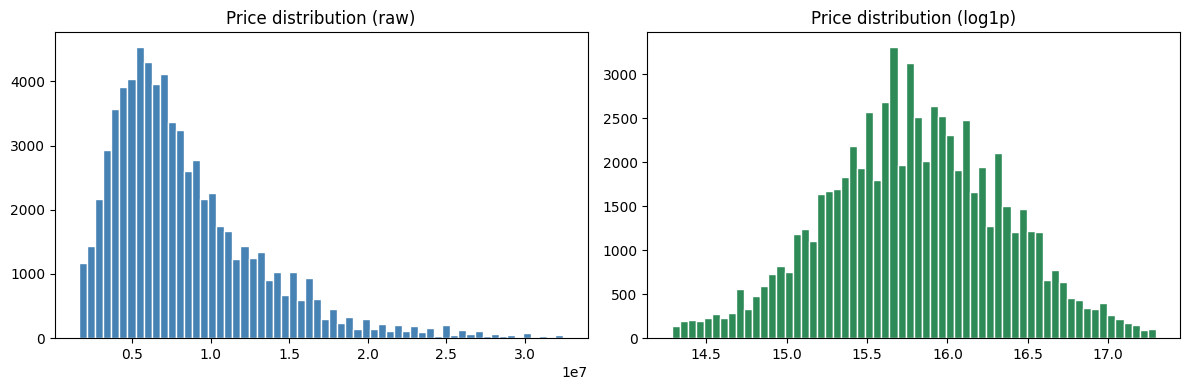

In [70]:
# ── Remove extreme price outliers (beyond 1.5 × IQR fence on log scale) ──
import numpy as np

log_price = np.log1p(df['price_numeric'])
Q1, Q3 = log_price.quantile(0.25), log_price.quantile(0.75)
IQR = Q3 - Q1
mask = (log_price >= Q1 - 1.5*IQR) & (log_price <= Q3 + 1.5*IQR)
print(f'Rows before outlier removal : {len(df):,}')
df = df[mask].reset_index(drop=True)
print(f'Rows after  outlier removal : {len(df):,}')

# ── Log1p-transform the target ─────────────────────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price_numeric'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price distribution (raw)')
axes[1].hist(np.log1p(df['price_numeric']), bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('Price distribution (log1p)')
plt.tight_layout(); plt.show()


In [87]:
df.to_csv('/content/processed_dubizzle_data.csv', index=False)
print('DataFrame saved to /content/processed_dubizzle_data.csv')

DataFrame saved to /content/processed_dubizzle_data.csv


# **9 — Train / Test Split**

In [71]:
from sklearn.model_selection import train_test_split

X = df.drop('price_numeric', axis=1)
y = np.log1p(df['price_numeric'])   # ← log1p-transformed target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'y_train mean={y_train.mean():.3f}  std={y_train.std():.3f}')

Train: (60280, 48)  |  Test: (10638, 48)
y_train mean=15.792  std=0.551


# **10 — Post-Split Encoding: Target Encoding for Categoricals**

Target encoding is applied **after** the split to prevent leakage.

In [72]:
from category_encoders import TargetEncoder

cols_target = X_train.select_dtypes(include='object').columns.tolist()
print('Columns to target-encode:', cols_target)

te = TargetEncoder(cols=cols_target, smoothing=10)   # smoothing reduces overfitting on rare categories
X_train = te.fit_transform(X_train, y_train)
X_test  = te.transform(X_test)
print('Encoding complete. Shape:', X_train.shape)

Columns to target-encode: ['property_type', 'city', 'governorate', 'finish_type', 'seller_name', 'view_type', 'compound_name']
Encoding complete. Shape: (60280, 48)


# **11 — Scaling: StandardScaler (fixed)**

**Bug fixed**: the original code fitted a *new* scaler per column, discarding the fitted state after each loop iteration — meaning `X_test` was scaled with the wrong parameters. Now we fit **one scaler on all numeric columns at once**.

In [73]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include='number').columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])  # fit on train only
X_test[num_cols]  = scaler.transform(X_test[num_cols])       # transform test with same params

print(f'Scaled {len(num_cols)} numeric columns.')
X_train.describe().round(3)

Scaled 36 numeric columns.


,bedrooms,bathrooms,area_sqm,area_numeric,property_type,city,governorate,latitude,longitude,finish_type,...,Central A/C & heating,Maids Room,roof,area_per_bedroom,area_per_bathroom,bed_bath_ratio,total_rooms,amenity_score,is_compound,delivery_bucket
count,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000,...,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000,60280.000
mean,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,...,-0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.226,-1.681,-0.014,-0.014,-3.333,-4.664,-9.924,-5.909,-5.765,-1.564,...,-0.399,-0.329,-0.294,-0.011,-0.011,-2.192,-2.143,-1.632,-1.952,-0.228
25%,-0.911,-0.457,-0.012,-0.012,-0.245,-0.518,-0.967,-0.031,-0.443,-0.737,...,-0.399,-0.329,-0.294,-0.010,-0.011,-0.509,-0.745,-0.861,0.512,-0.228
50%,0.405,-0.457,-0.012,-0.012,-0.245,0.249,0.508,0.055,0.209,-0.562,...,-0.399,-0.329,-0.294,-0.010,-0.010,-0.509,-0.046,0.166,0.512,-0.228
75%,0.405,0.767,-0.011,-0.011,-0.245,0.820,0.508,0.107,0.365,1.481,...,-0.399,-0.329,-0.294,-0.010,-0.010,0.669,0.653,0.680,0.512,-0.228
max,9.613,9.333,140.492,140.492,2.834,3.449,2.665,2.466,4.058,3.491,...,2.505,3.043,3.407,141.423,141.381,20.697,10.438,2.222,0.512,6.351


# **12 — Model Training & Evaluation (SOTA)**

## 12.1 — Setup & Evaluation Helpers

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

def evaluate(name, y_true, y_pred_log, verbose=True):
    """Evaluate in log space AND original EGP space."""
    # log-space metrics
    r2   = r2_score(y_true, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred_log))
    # original-space metrics (expm1 reverses log1p)
    y_true_egp = np.expm1(y_true)
    y_pred_egp = np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_true_egp, y_pred_egp)
    rmse = np.sqrt(mean_squared_error(y_true_egp, y_pred_egp))
    mape = np.mean(np.abs((y_true_egp - y_pred_egp) / np.clip(y_true_egp, 1, None))) * 100
    if verbose:
        print(f'┌─ {name}')
        print(f'│  R²          : {r2:.4f}')
        print(f'│  RMSE (log)  : {rmse_log:.4f}')
        print(f'│  MAE  (EGP)  : {mae:>15,.0f}')
        print(f'│  RMSE (EGP)  : {rmse:>15,.0f}')
        print(f'└  MAPE        : {mape:.2f}%\n')
    return {'name': name, 'r2': r2, 'rmse_log': rmse_log, 'mae': mae, 'rmse': rmse, 'mape': mape}

def plot_residuals(name, y_true, y_pred_log):
    residuals = y_true - y_pred_log
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    # Predicted vs Actual
    axes[0].scatter(y_true, y_pred_log, alpha=0.25, s=10, color='steelblue')
    lims = [min(y_true.min(), y_pred_log.min()), max(y_true.max(), y_pred_log.max())]
    axes[0].plot(lims, lims, 'r--', lw=1.5)
    axes[0].set(xlabel='Actual (log)', ylabel='Predicted (log)', title=f'{name}: Predicted vs Actual')
    # Residual vs Predicted
    axes[1].scatter(y_pred_log, residuals, alpha=0.25, s=10, color='darkorange')
    axes[1].axhline(0, color='r', lw=1.5, linestyle='--')
    axes[1].set(xlabel='Predicted (log)', ylabel='Residual', title='Residuals vs Predicted')
    # Residual distribution
    axes[2].hist(residuals, bins=50, color='seagreen', edgecolor='white')
    axes[2].set(xlabel='Residual', title='Residual Distribution')
    plt.suptitle(name, fontweight='bold'); plt.tight_layout(); plt.show()

results = []   # will collect dicts from evaluate()

## 12.2 — LightGBM (baseline tuned)

In [75]:
import lightgbm as lgb

lgb_params = dict(
    n_estimators    = 3000,
    learning_rate   = 0.03,
    max_depth       = -1,          # unlimited, controlled by num_leaves
    num_leaves      = 63,          # 2^depth-1 rule: 2^6-1
    min_child_samples = 20,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,         # L1
    reg_lambda      = 1.0,         # L2
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1,
)

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)],
)
lgb_preds = lgb_model.predict(X_test)
results.append(evaluate('LightGBM (baseline)', y_test, lgb_preds))

[500]	valid_0's l2: 0.0586977
[1000]	valid_0's l2: 0.0532516
[1500]	valid_0's l2: 0.0505593
[2000]	valid_0's l2: 0.0489741
[2500]	valid_0's l2: 0.0479499
[3000]	valid_0's l2: 0.0470676
┌─ LightGBM (baseline)
│  R²          : 0.8443
│  RMSE (log)  : 0.2170
│  MAE  (EGP)  :       1,280,206
│  RMSE (EGP)  :       2,046,598
└  MAPE        : 15.82%



## 12.3 — Optuna Hyperparameter Search (LightGBM)

In [ ]:
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 500, 4000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 31, 255),
        'max_depth'         : trial.suggest_int('max_depth', 4, 12),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 100),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state'      : 42,
        'n_jobs'            : -1,
        'verbose'           : -1,
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = -cross_val_score(
        lgb.LGBMRegressor(**params), X_train, y_train,
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print('Best CV RMSE (log):', round(study.best_value, 5))
print('Best params:', study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-04-25 18:38:34,483] Trial 3 failed with parameters: {'n_estimators': 1897, 'learning_rate': 0.020590178154379978, 'num_leaves': 40, 'max_depth': 6, 'min_child_samples': 99, 'subsample': 0.8433059915758383, 'colsample_bytree': 0.567860870060971, 'reg_alpha': 6.286372720627725, 'reg_lambda': 0.5751965401934481} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_8513/3680403413.py", line 21, in lgb_objective
    scores = -cross_val_score(
              ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 684, in cross_val_score
   

KeyboardInterrupt: 

In [ ]:
# ── Train final LightGBM with best params ──────────────────────────────
best_lgb = lgb.LGBMRegressor(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
best_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(100, verbose=False)],
)
lgb_preds = best_lgb.predict(X_test)
results.append(evaluate('LightGBM (Optuna-tuned)', y_test, lgb_preds))
plot_residuals('LightGBM (Optuna-tuned)', y_test, lgb_preds)

KeyboardInterrupt: 

## 12.4 — XGBoost

In [76]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators      = 3000,
    learning_rate     = 0.03,
    max_depth         = 8,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    min_child_weight  = 5,
    gamma             = 0.1,
    n_jobs            = -1,
    random_state      = 42,
    objective         = 'reg:squarederror',
    early_stopping_rounds = 100,
    eval_metric       = 'rmse',
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=500)
xgb_preds = xgb_model.predict(X_test)
results.append(evaluate('XGBoost', y_test, xgb_preds))

[0]	validation_0-rmse:0.54045
[500]	validation_0-rmse:0.23694
[1000]	validation_0-rmse:0.23168
[1500]	validation_0-rmse:0.23071
[2000]	validation_0-rmse:0.23017
[2500]	validation_0-rmse:0.22979
[2834]	validation_0-rmse:0.22972
┌─ XGBoost
│  R²          : 0.8254
│  RMSE (log)  : 0.2297
│  MAE  (EGP)  :       1,379,490
│  RMSE (EGP)  :       2,177,686
└  MAPE        : 17.02%



## 12.5 — CatBoost

In [77]:
try:
    from catboost import CatBoostRegressor, Pool
except ImportError:
    import subprocess; subprocess.run(['pip','install','catboost','-q'])
    from catboost import CatBoostRegressor, Pool

# CatBoost works best with its own raw categorical columns.
# Since we've already encoded, we pass the fully numeric data.
cb_model = CatBoostRegressor(
    iterations        = 3000,
    learning_rate     = 0.03,
    depth             = 8,
    l2_leaf_reg       = 3.0,
    border_count      = 128,
    loss_function     = 'RMSE',
    eval_metric       = 'RMSE',
    od_type           = 'Iter',
    od_wait           = 100,
    random_seed       = 42,
    verbose           = 500,
)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test))
cb_preds = cb_model.predict(X_test)
results.append(evaluate('CatBoost', y_test, cb_preds))

0:	learn: 0.5410105	test: 0.5406736	best: 0.5406736 (0)	total: 99.5ms	remaining: 4m 58s
500:	learn: 0.2388061	test: 0.2656023	best: 0.2656023 (500)	total: 12s	remaining: 1m
1000:	learn: 0.2147801	test: 0.2487091	best: 0.2487091 (1000)	total: 30s	remaining: 59.9s
1500:	learn: 0.2000556	test: 0.2396261	best: 0.2396261 (1500)	total: 56.1s	remaining: 56s
2000:	learn: 0.1891874	test: 0.2340398	best: 0.2340398 (2000)	total: 1m 8s	remaining: 34.4s
2500:	learn: 0.1800079	test: 0.2299597	best: 0.2299597 (2500)	total: 1m 22s	remaining: 16.4s
2999:	learn: 0.1727582	test: 0.2271267	best: 0.2271267 (2999)	total: 1m 34s	remaining: 0us

bestTest = 0.2271267008
bestIteration = 2999

┌─ CatBoost
│  R²          : 0.8293
│  RMSE (log)  : 0.2271
│  MAE  (EGP)  :       1,385,478
│  RMSE (EGP)  :       2,176,973
└  MAPE        : 16.96%



## 12.6 — Neural Network (Residual MLP)

In [80]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_residual_mlp(input_dim):
    """Residual MLP: each block adds a skip-connection so gradients flow."""
    inp = tf.keras.Input(shape=(input_dim,))
    x = layers.Dense(512, activation='swish')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Residual block 1
    h = layers.Dense(256, activation='swish')(x)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(0.2)(h)
    h = layers.Dense(256, activation='swish')(h)
    # project x to 256 dims for the skip connection
    x = layers.Dense(256)(x)
    x = layers.Add()([x, h])

    # Residual block 2
    h = layers.Dense(128, activation='swish')(x)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(0.2)(h)
    h = layers.Dense(128, activation='swish')(h)
    x = layers.Dense(128)(x)
    x = layers.Add()([x, h])

    out = layers.Dense(1)(x)
    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss='huber',       # robust to remaining outliers
        metrics=['mae']
    )
    return model

nn_model = build_residual_mlp(X_train.shape[1])
nn_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
]

history = nn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200, batch_size=256,
    callbacks=callbacks, verbose=0
)

# Plot learning curves
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Huber Loss')
plt.plot(history.history['val_loss'], label='Val Huber Loss')
plt.title('Residual MLP — Learning Curves'); plt.legend(); plt.show()

dl_preds = nn_model.predict(X_test, verbose=0).flatten()
results.append(evaluate('Residual MLP (Keras)', y_test, dl_preds))

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 512)       │     25,088 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_16[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 256)       │    131,328 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_17[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256)       │    131,328 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │     65,792 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256)       │          0 │ dense_19[0][0],   │
│                     │                   │            │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │     32,896 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │     32,896 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 128)       │     16,512 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 128)       │          0 │ dense_22[0][0],   │
│                     │                   │            │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 1)         │        129 │ add_5[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 439,553 (1.68 MB)

 Trainable params: 437,761 (1.67 MB)

 Non-trainable params: 1,792 (7.00 KB)

KeyboardInterrupt: 

## 12.7 — Stacking Ensemble (out-of-fold, cross-validated)

Instead of naïve weighted averaging, we use `StackingRegressor` with out-of-fold predictions as meta-features and a Ridge meta-learner. This lets the meta-model learn optimal blending weights.

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

estimators = [
    ('lgb', lgb_model),
    ('xgb', xgb_model),
    ('cb',  cb_model),
]

stack = StackingRegressor(
    estimators    = estimators,
    final_estimator = Ridge(alpha=1.0),
    cv            = KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs        = -1,
    passthrough   = False,   # only pass OOF preds as meta-features
)
stack.fit(X_train, y_train)
stack_preds = stack.predict(X_test)
results.append(evaluate('Stacking (LGB+XGB+CB → Ridge)', y_test, stack_preds))
plot_residuals('Stacking Ensemble', y_test, stack_preds)

## 12.8 — Optimised Weighted Blend

In [ ]:
from scipy.optimize import minimize

preds_matrix = np.column_stack([lgb_preds, xgb_preds, cb_preds, dl_preds, stack_preds])
model_names  = ['LGB_tuned', 'XGB', 'CB', 'MLP', 'Stack']

def blend_rmse(weights):
    w = np.abs(weights) / np.abs(weights).sum()   # normalise
    blended = preds_matrix @ w
    return np.sqrt(mean_squared_error(y_test, blended))

w0 = np.ones(len(model_names)) / len(model_names)
result = minimize(blend_rmse, w0, method='Nelder-Mead',
                  options={'maxiter': 5000, 'xatol': 1e-8})
opt_weights = np.abs(result.x) / np.abs(result.x).sum()

print('Optimised blend weights:')
for n, w in zip(model_names, opt_weights):
    print(f'  {n:<15} : {w:.4f}')

blend_preds = preds_matrix @ opt_weights
results.append(evaluate('Optimised Weighted Blend', y_test, blend_preds))
plot_residuals('Optimised Weighted Blend', y_test, blend_preds)

## 12.9 — Results Summary

In [81]:
import pandas as pd
results_df = pd.DataFrame(results).set_index('name').sort_values('r2', ascending=False)
results_df['mae'] = results_df['mae'].apply(lambda x: f'{x:,.0f} EGP')
results_df['rmse'] = results_df['rmse'].apply(lambda x: f'{x:,.0f} EGP')
results_df['mape'] = results_df['mape'].apply(lambda x: f'{x:.2f}%')
results_df.rename(columns={'r2':'R²','rmse_log':'RMSE (log)'}, inplace=True)
print('\n======= MODEL LEADERBOARD =======')
print(results_df.to_string())


======= MODEL LEADERBOARD =======
                           R²  RMSE (log)            mae           rmse    mape
name                                                                           
LightGBM (baseline)  0.844272    0.216951  1,280,206 EGP  2,046,598 EGP  15.82%
CatBoost             0.829321    0.227127  1,385,478 EGP  2,176,973 EGP  16.96%
XGBoost              0.825413    0.229712  1,379,490 EGP  2,177,686 EGP  17.02%


## 12.10 — Model Interpretability (SHAP)

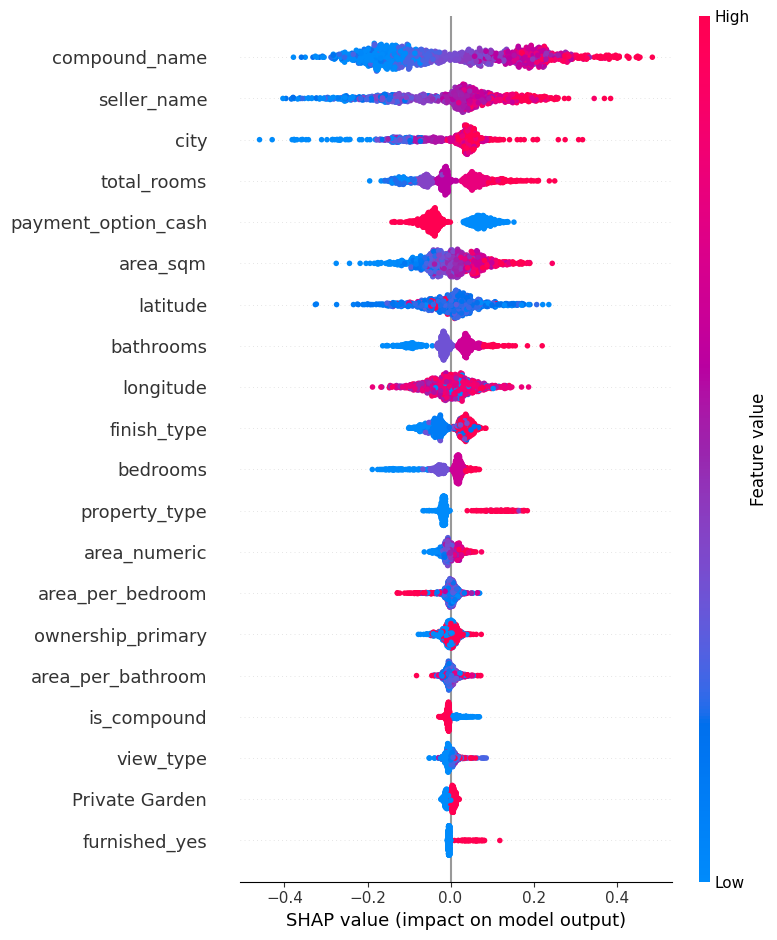

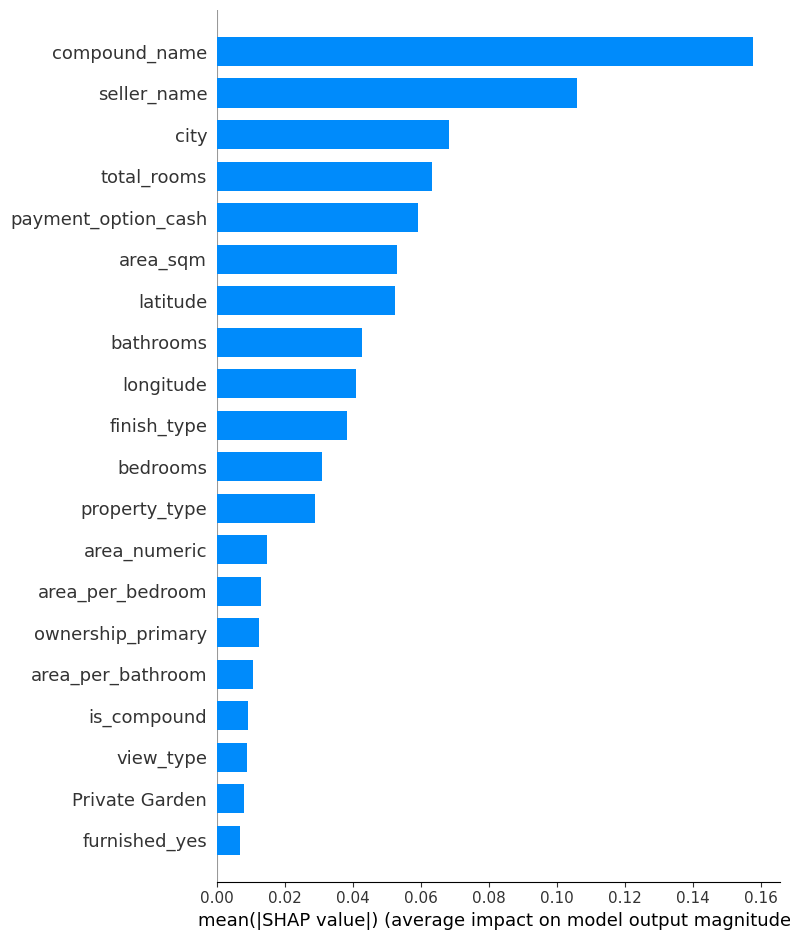

In [83]:
import shap

# Use the best single model (Optuna-tuned LightGBM) for SHAP
explainer   = shap.TreeExplainer(lgb_model)
sample_size = min(1000, len(X_test))
X_sample    = X_test.iloc[:sample_size]
shap_values = explainer.shap_values(X_sample)

# Beeswarm: global feature importance
shap.summary_plot(shap_values, X_sample, max_display=20, plot_type='dot',
                  title='SHAP — Feature Impact on log(Price)')

# Bar chart
shap.summary_plot(shap_values, X_sample, max_display=20, plot_type='bar')

## 12.11 — Save Models & Preprocessors

In [86]:
import joblib, os

os.makedirs('saved_models', exist_ok=True)

# Preprocessors
joblib.dump(te,     'saved_models/target_encoder.pkl')
joblib.dump(scaler, 'saved_models/standard_scaler.pkl')

# Models
lgb_model.booster_.save_model('saved_models/lgb_optuna.txt')
xgb_model.save_model('saved_models/xgb_model.json')
cb_model.save_model('saved_models/cb_model.cbm')
# nn_model.save('saved_models/residual_mlp.keras')
# joblib.dump(stack, 'saved_models/stacking_ensemble.pkl')

# Save Optuna study
# joblib.dump(study, 'saved_models/optuna_lgb_study.pkl')

print('✅ All models and preprocessors saved to saved_models/')

# ── Inference helper ────────────────────────────────────────────────────
def predict_price_egp(raw_df, model=lgb_model):
    """End-to-end inference: raw dataframe → EGP price."""
    enc = te.transform(raw_df)
    enc[num_cols] = scaler.transform(enc[num_cols])
    log_pred = model.predict(enc)
    return np.expm1(log_pred)   # back to EGP

print('predict_price_egp() helper defined and ready.')

✅ All models and preprocessors saved to saved_models/
predict_price_egp() helper defined and ready.
